<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

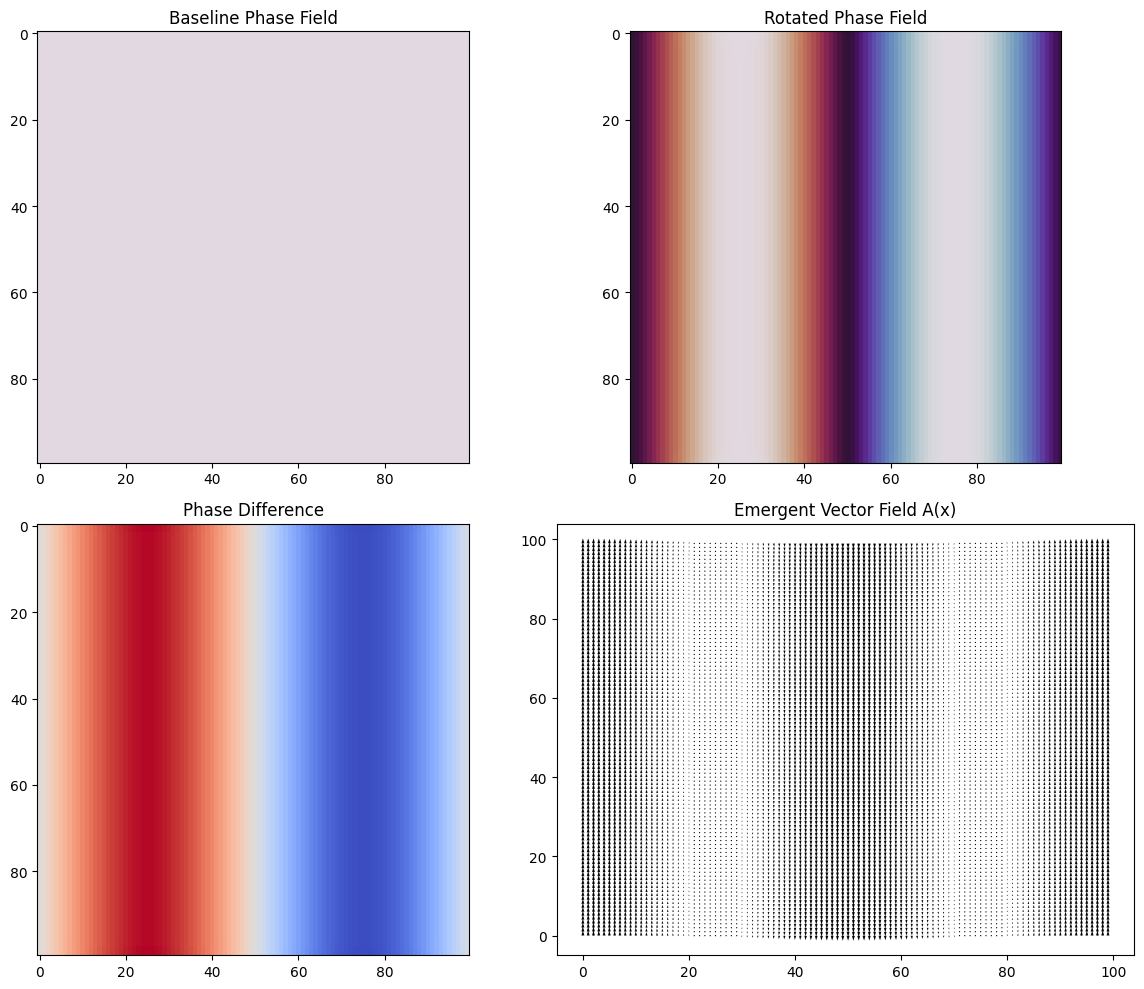

In [1]:
# Phase Rotation Test for Emergent Gauge Symmetry in HES Lattice
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 100  # Lattice size
epsilon = 0.1
k = 2 * np.pi / L
timesteps = 50

# Initialize complex-valued attractor field ψ(x)
psi = np.exp(1j * np.zeros((L, L)))  # Uniform phase

# Define spatially varying phase rotation θ(x)
x = np.arange(L)
theta = epsilon * np.sin(k * x)
theta_2d = np.tile(theta, (L, 1))  # Broadcast across rows

# Apply phase rotation: ψ(x) → ψ(x) * exp(iθ(x))
psi_rotated = psi * np.exp(1j * theta_2d)

# Evolution function: simplified HES dynamics (diffusion + entropic compensation)
def evolve(psi_field):
    new_field = np.copy(psi_field)
    for i in range(1, L-1):
        for j in range(1, L-1):
            laplacian = (
                psi_field[i+1, j] + psi_field[i-1, j] +
                psi_field[i, j+1] + psi_field[i, j-1] - 4 * psi_field[i, j]
            )
            compensation = 0.05 * laplacian  # Entropic gradient term
            new_field[i, j] += compensation
    return new_field

# Run evolution for baseline and rotated fields
psi_evolved = psi.copy()
psi_rotated_evolved = psi_rotated.copy()
for _ in range(timesteps):
    psi_evolved = evolve(psi_evolved)
    psi_rotated_evolved = evolve(psi_rotated_evolved)

# Diagnostics
phase_baseline = np.angle(psi_evolved)
phase_rotated = np.angle(psi_rotated_evolved)
phase_diff = phase_rotated - phase_baseline

# Emergent vector field A(x): gradient of phase difference
Ax, Ay = np.gradient(phase_diff)

# Plot results
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].imshow(phase_baseline, cmap='twilight')
axs[0, 0].set_title("Baseline Phase Field")

axs[0, 1].imshow(phase_rotated, cmap='twilight')
axs[0, 1].set_title("Rotated Phase Field")

axs[1, 0].imshow(phase_diff, cmap='coolwarm')
axs[1, 0].set_title("Phase Difference")

axs[1, 1].quiver(Ax, Ay)
axs[1, 1].set_title("Emergent Vector Field A(x)")

plt.tight_layout()
plt.show()
